# 🧠 Denoising Autoencoder using MNIST

## 👨‍💻 Machine Learning Foundation – Week 6

### 🎯 Celebal Technologies Internship

---

## 📌 Project Objective

The objective of this project is to build a **Convolutional Denoising Autoencoder** using the **MNIST handwritten digit dataset**. The model is trained to reconstruct clean handwritten digit images from noisy inputs by learning compressed latent representations through an encoder-decoder architecture.

This project demonstrates the application of deep learning techniques for image denoising, feature extraction, and image reconstruction in computer vision.

# 📊 Executive Summary

This project focuses on developing a **Convolutional Denoising Autoencoder** capable of restoring clean handwritten digit images from noisy inputs using the **MNIST dataset**.

Initially, Gaussian noise is artificially added to the original images to simulate corrupted data. The noisy images are then used as inputs to train the Autoencoder, while the corresponding clean images serve as target outputs. The model consists of an encoder that extracts meaningful latent features and a decoder that reconstructs high-quality images from these compressed representations.

Model performance is evaluated using training and validation loss, along with visual comparisons between the original, noisy, and reconstructed images. The results demonstrate the effectiveness of Autoencoders in image denoising and highlight their importance in image restoration and representation learning tasks.

# 📚 Import Required Libraries

In [1]:
# Numerical Computation
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Deep Learning
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# 📂 Load the MNIST Dataset

In [2]:
# Load MNIST Dataset

(x_train, _), (x_test, _) = mnist.load_data()

print("Training Images :", x_train.shape)
print("Testing Images  :", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)


# 🔍 Explore the Dataset

In [3]:
print("Image Shape :", x_train[0].shape)

print("\nPixel Value Range")

print("Minimum :", x_train.min())

print("Maximum :", x_train.max())

Image Shape : (28, 28)

Pixel Value Range
Minimum : 0
Maximum : 255


# 🖼 Visualize Original Images

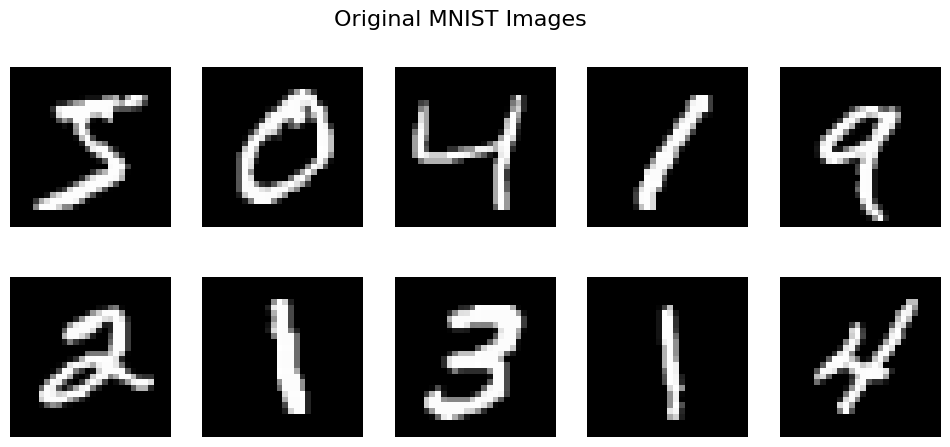

In [4]:
plt.figure(figsize=(12,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(x_train[i], cmap='gray')

    plt.axis('off')

plt.suptitle("Original MNIST Images", fontsize=16)

plt.show()

# ⚙ Normalize the Images

In [5]:
# Normalize pixel values to the range [0, 1]

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training Data Shape :", x_train.shape)
print("Testing Data Shape  :", x_test.shape)

print("\nPixel Value Range")

print("Minimum :", x_train.min())
print("Maximum :", x_train.max())

Training Data Shape : (60000, 28, 28)
Testing Data Shape  : (10000, 28, 28)

Pixel Value Range
Minimum : 0.0
Maximum : 1.0


# 🔄 Reshape Images for CNN

In [6]:
# Reshape images to (28, 28, 1)

x_train = np.reshape(x_train, (-1, 28, 28, 1))
x_test = np.reshape(x_test, (-1, 28, 28, 1))

print("Training Shape :", x_train.shape)
print("Testing Shape  :", x_test.shape)

Training Shape : (60000, 28, 28, 1)
Testing Shape  : (10000, 28, 28, 1)


# 🌧 Add Gaussian Noise to Images

In [7]:
# Add Gaussian Noise

noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

# Keep pixel values between 0 and 1

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Noise Added Successfully!")

Noise Added Successfully!


# 🖼 Visualize Noisy Images

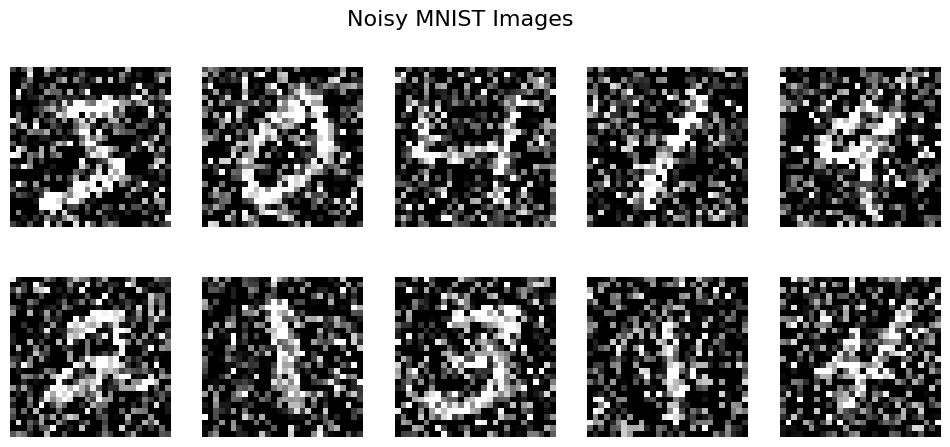

In [8]:
plt.figure(figsize=(12,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')

    plt.axis('off')

plt.suptitle("Noisy MNIST Images", fontsize=16)

plt.show()

# 📊 Compare Original and Noisy Images

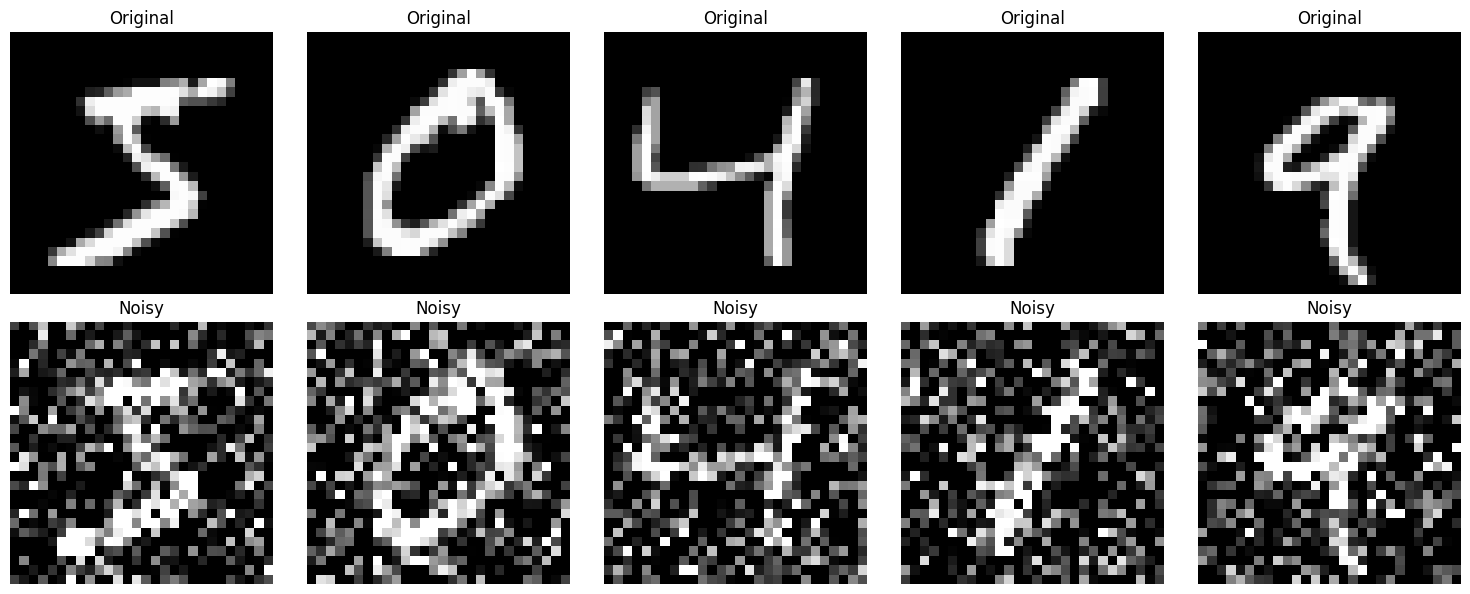

In [9]:
plt.figure(figsize=(15,6))

for i in range(5):

    # Original Image
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy Image
    plt.subplot(2,5,i+6)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.tight_layout()

plt.show()

# 🧠 Build the Denoising Autoencoder

In [10]:
# Input Layer

input_img = Input(shape=(28, 28, 1))

## 🔽 Encoder

In [11]:
# Encoder

x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

print("Encoder Created Successfully")

Encoder Created Successfully


## 🔼 Decoder

In [12]:
# Decoder

x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

print("Decoder Created Successfully")

Decoder Created Successfully


# 🤖 Create the Autoencoder Model

In [13]:
autoencoder = Model(input_img, decoded)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

# ⚙ Compile the Model

In [14]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

print("Model Compiled Successfully")

Model Compiled Successfully


# ⏹ Configure EarlyStopping

In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("EarlyStopping Configured")

EarlyStopping Configured


# 🚀 Train the Autoencoder

In [16]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[early_stop]
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.1544 - val_loss: 0.1133
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1105 - val_loss: 0.1056
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1050 - val_loss: 0.1021
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1019 - val_loss: 0.0999
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1001 - val_loss: 0.0987
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0988 - val_loss: 0.0975
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0978 - val_loss: 0.0967
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0971 - val_loss: 0.0961
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0965 - val_loss: 0.0956
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0960 - val_loss: 0.0952
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0956 - val_loss: 0.0949
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/st

# 📉 Plot Training and Validation Loss

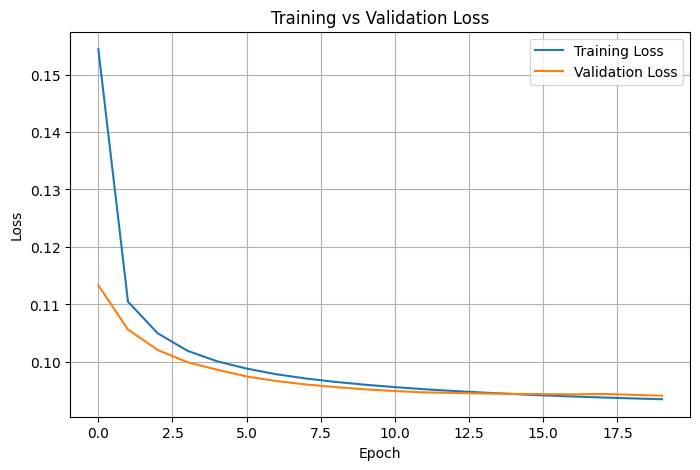

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

# ✨ Generate Denoised Images

In [18]:
# Generate reconstructed (denoised) images

decoded_images = autoencoder.predict(x_test_noisy)

print("Denoised images generated successfully!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Denoised images generated successfully!


# 🖼 Compare Original, Noisy, and Reconstructed Images

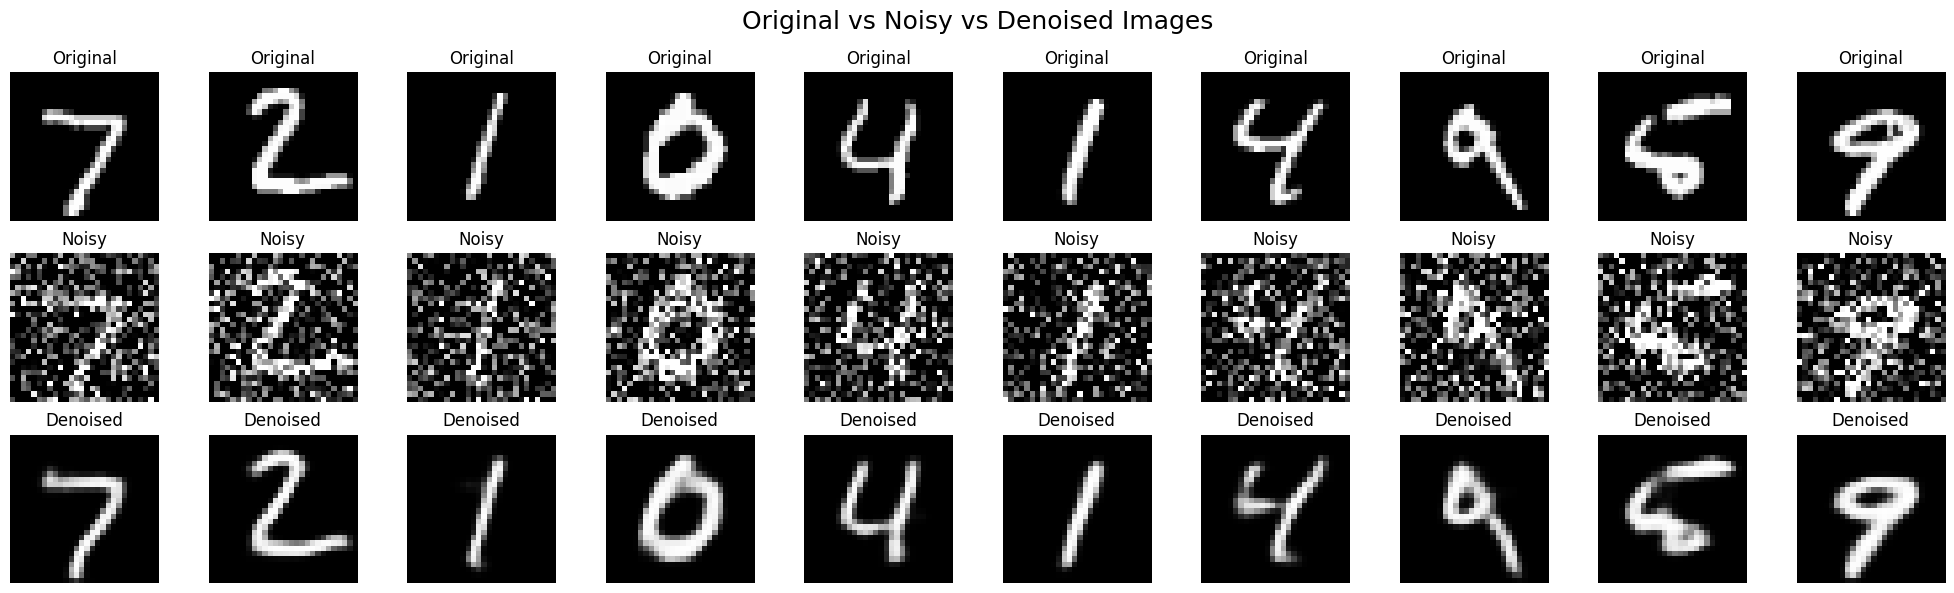

In [19]:
n = 10

plt.figure(figsize=(20, 6))

for i in range(n):

    # Original Image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy Image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Reconstructed Image
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_images[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.suptitle("Original vs Noisy vs Denoised Images", fontsize=18)

plt.tight_layout()

plt.show()

# 📌 Project Summary

This project successfully demonstrated the implementation of a Convolutional Denoising Autoencoder using the MNIST handwritten digit dataset.

The model learned to reconstruct clean handwritten digit images from noisy inputs using an encoder-decoder architecture. The visual comparison between original, noisy, and reconstructed images shows that the model effectively reduced Gaussian noise while preserving the important features of each digit.

The results demonstrate the usefulness of Autoencoders for image denoising and representation learning in computer vision.

# 📊 Model Performance Analysis

## 🔍 Observations

- The Autoencoder successfully learned to reconstruct clean handwritten digit images from noisy inputs.
- The reconstructed images contain significantly less Gaussian noise than the input images.
- Training and validation loss decreased steadily, indicating effective learning.
- The model preserved important digit features while removing random noise.
- EarlyStopping helped reduce overfitting by restoring the best-performing model.
- The Convolutional Autoencoder effectively extracted meaningful latent features for image reconstruction.

# 🎯 Final Insights & Conclusion

## 📝 Conclusion

The objective of this project was to build a **Denoising Autoencoder** capable of reconstructing clean handwritten digit images from noisy inputs using the MNIST dataset.

The Convolutional Autoencoder effectively learned compressed feature representations through its encoder-decoder architecture and successfully reconstructed high-quality images after training.

The comparison between the original, noisy, and reconstructed images demonstrates that the model can remove a significant amount of Gaussian noise while preserving important digit characteristics.

Overall, the project highlights the effectiveness of Autoencoders for image denoising, feature extraction, and representation learning, making them valuable for various computer vision and deep learning applications.

# ✅ Key Learning Outcomes

- Understanding Autoencoders
- Image Reconstruction
- Gaussian Noise Generation
- CNN-based Encoder-Decoder Architecture
- Feature Extraction
- Image Denoising
- TensorFlow/Keras Model Development
- Deep Learning for Computer Vision